# PREPROCESSING

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path

DATA_DIR = Path("/content/raw_dataset")

parquet_files = sorted(DATA_DIR.glob("*.parquet"))

print("Number of Parquet files:", len(parquet_files))

for file in parquet_files:
    print(file.name)

Number of Parquet files: 8
Benign-Monday-no-metadata.parquet
Botnet-Friday-no-metadata.parquet
Bruteforce-Tuesday-no-metadata.parquet
DDoS-Friday-no-metadata.parquet
DoS-Wednesday-no-metadata.parquet
Infiltration-Thursday-no-metadata.parquet
Portscan-Friday-no-metadata.parquet
WebAttacks-Thursday-no-metadata.parquet


In [2]:
for file in parquet_files:

    df = pd.read_parquet(file)

    print("=" * 80)
    print(file.name)
    print("Shape:", df.shape)
    print("Columns:", len(df.columns))

    print("\nLabels:")
    print(df["Label"].value_counts())

    print()

Benign-Monday-no-metadata.parquet
Shape: (458831, 78)
Columns: 78

Labels:
Label
Benign    458831
Name: count, dtype: int64

Botnet-Friday-no-metadata.parquet
Shape: (176038, 78)
Columns: 78

Labels:
Label
Benign    174601
Bot         1437
Name: count, dtype: int64

Bruteforce-Tuesday-no-metadata.parquet
Shape: (389714, 78)
Columns: 78

Labels:
Label
Benign         380564
FTP-Patator      5931
SSH-Patator      3219
Name: count, dtype: int64

DDoS-Friday-no-metadata.parquet
Shape: (221264, 78)
Columns: 78

Labels:
Label
DDoS      128014
Benign     93250
Name: count, dtype: int64

DoS-Wednesday-no-metadata.parquet
Shape: (584991, 78)
Columns: 78

Labels:
Label
Benign              391235
DoS Hulk            172846
DoS GoldenEye        10286
DoS slowloris         5385
DoS Slowhttptest      5228
Heartbleed              11
Name: count, dtype: int64

Infiltration-Thursday-no-metadata.parquet
Shape: (207630, 78)
Columns: 78

Labels:
Label
Benign          207594
Infiltration        36
Name: cou

In [3]:
label_mapping = {
    "Web Attack � Brute Force": "Web Attack - Brute Force",
    "Web Attack � XSS": "Web Attack - XSS",
    "Web Attack � Sql Injection": "Web Attack - SQL Injection"
}

dfs = []

for file in parquet_files:

    print(f"Loading: {file.name}")

    temp = pd.read_parquet(file)

    # Remove leading/trailing spaces from column names
    temp.columns = temp.columns.str.strip()

    # Clean label formatting
    temp["Label"] = temp["Label"].astype(str).str.strip()

    # Standardize inconsistent web-attack labels
    temp["Label"] = temp["Label"].replace(label_mapping)

    dfs.append(temp)

combined_df = pd.concat(
    dfs,
    ignore_index=True
)

print("\nCombined shape:", combined_df.shape)

Loading: Benign-Monday-no-metadata.parquet
Loading: Botnet-Friday-no-metadata.parquet
Loading: Bruteforce-Tuesday-no-metadata.parquet
Loading: DDoS-Friday-no-metadata.parquet
Loading: DoS-Wednesday-no-metadata.parquet
Loading: Infiltration-Thursday-no-metadata.parquet
Loading: Portscan-Friday-no-metadata.parquet
Loading: WebAttacks-Thursday-no-metadata.parquet

Combined shape: (2313810, 78)


In [4]:
print("Number of columns:", len(combined_df.columns))

print("\nColumns:")
print(combined_df.columns.tolist())

print("\nLabels:")
print(combined_df["Label"].value_counts())

Number of columns: 78

Columns:
['Protocol', 'Flow Duration', 'Total Fwd Packets', 'Total Backward Packets', 'Fwd Packets Length Total', 'Bwd Packets Length Total', 'Fwd Packet Length Max', 'Fwd Packet Length Min', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max', 'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags', 'Bwd PSH Flags', 'Fwd URG Flags', 'Bwd URG Flags', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Bwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count', 'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', 'URG Flag Count', 'CWE Flag Count

In [5]:
print(combined_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2313810 entries, 0 to 2313809
Data columns (total 78 columns):
 #   Column                    Dtype  
---  ------                    -----  
 0   Protocol                  int8   
 1   Flow Duration             int32  
 2   Total Fwd Packets         int32  
 3   Total Backward Packets    int32  
 4   Fwd Packets Length Total  int32  
 5   Bwd Packets Length Total  int32  
 6   Fwd Packet Length Max     int16  
 7   Fwd Packet Length Min     int16  
 8   Fwd Packet Length Mean    float32
 9   Fwd Packet Length Std     float32
 10  Bwd Packet Length Max     int16  
 11  Bwd Packet Length Min     int16  
 12  Bwd Packet Length Mean    float32
 13  Bwd Packet Length Std     float32
 14  Flow Bytes/s              float64
 15  Flow Packets/s            float64
 16  Flow IAT Mean             float32
 17  Flow IAT Std              float32
 18  Flow IAT Max              int32  
 19  Flow IAT Min              int32  
 20  Fwd IAT Total           

In [6]:
duplicate_count = combined_df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

print(
    "Duplicate percentage:",
    round(duplicate_count / len(combined_df) * 100, 3),
    "%"
)

Duplicate rows: 82004
Duplicate percentage: 3.544 %


In [7]:
before = len(combined_df)

combined_df = (
    combined_df
    .drop_duplicates()
    .reset_index(drop=True)
)

after = len(combined_df)

print("Rows before:", before)
print("Rows after :", after)
print("Removed    :", before - after)

Rows before: 2313810
Rows after : 2231806
Removed    : 82004


In [8]:
print(combined_df["Label"].value_counts())

Label
Benign                        1895314
DoS Hulk                       172846
DDoS                           128014
DoS GoldenEye                   10286
FTP-Patator                      5931
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3219
PortScan                         1956
Web Attack - Brute Force         1470
Bot                              1437
Web Attack - XSS                  652
Infiltration                       36
Web Attack - SQL Injection         21
Heartbleed                         11
Name: count, dtype: int64


In [9]:
missing_values = combined_df.isnull().sum()

print("Columns with missing values:")
print(
    missing_values[missing_values > 0]
    .sort_values(ascending=False)
)

print("\nTotal missing values:", missing_values.sum())

Columns with missing values:
Series([], dtype: int64)

Total missing values: 0


In [10]:
numeric_cols = combined_df.select_dtypes(include=np.number).columns

inf_counts = np.isinf(combined_df[numeric_cols]).sum()

print("Columns containing infinite values:")

print(
    inf_counts[inf_counts > 0]
    .sort_values(ascending=False)
)

Columns containing infinite values:
Series([], dtype: int64)


In [11]:
negative_counts = {}

for col in numeric_cols:

    count = (combined_df[col] < 0).sum()

    if count > 0:
        negative_counts[col] = count

print("Columns containing negative values:")
print(negative_counts)

Columns containing negative values:
{'Flow Duration': np.int64(82), 'Flow Bytes/s': np.int64(53), 'Flow Packets/s': np.int64(82), 'Flow IAT Mean': np.int64(82), 'Flow IAT Max': np.int64(82), 'Flow IAT Min': np.int64(2801), 'Fwd IAT Min': np.int64(17), 'Fwd Header Length': np.int64(35), 'Bwd Header Length': np.int64(22), 'Init Fwd Win Bytes': np.int64(909578), 'Init Bwd Win Bytes': np.int64(1120793), 'Fwd Seg Size Min': np.int64(35)}


In [12]:
invalid_negative_cols = [
    "Flow Duration",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Flow IAT Mean",
    "Flow IAT Max",
    "Flow IAT Min",
    "Fwd IAT Min",
    "Fwd Header Length",
    "Bwd Header Length",
    "Fwd Seg Size Min"
]

invalid_mask = (
    combined_df[invalid_negative_cols] < 0
).any(axis=1)

print(
    "Rows containing invalid negative values:",
    invalid_mask.sum()
)

Rows containing invalid negative values: 2836


In [13]:
before = len(combined_df)

combined_df = (
    combined_df.loc[~invalid_mask]
    .reset_index(drop=True)
)

after = len(combined_df)

print("Rows before:", before)
print("Rows after :", after)
print("Removed    :", before - after)

Rows before: 2231806
Rows after : 2228970
Removed    : 2836


In [14]:
sentinel_cols = [
    "Init Fwd Win Bytes",
    "Init Bwd Win Bytes"
]

for col in sentinel_cols:
    combined_df[col] = combined_df[col].replace(-1, np.nan)

print(combined_df[sentinel_cols].isna().sum())

Init Fwd Win Bytes     909527
Init Bwd Win Bytes    1120742
dtype: int64


In [15]:
nunique = combined_df.nunique()

constant_features = nunique[nunique <= 1]

print("Constant features:")
print(constant_features)

Constant features:
Bwd PSH Flags           1
Bwd URG Flags           1
Fwd Avg Bytes/Bulk      1
Fwd Avg Packets/Bulk    1
Fwd Avg Bulk Rate       1
Bwd Avg Bytes/Bulk      1
Bwd Avg Packets/Bulk    1
Bwd Avg Bulk Rate       1
dtype: int64


In [16]:
constant_features = constant_features.index.tolist()

combined_df.drop(
    columns=constant_features,
    inplace=True
)

print("Removed constant features:", len(constant_features))
print("New shape:", combined_df.shape)

Removed constant features: 8
New shape: (2228970, 70)


In [17]:
print("=" * 60)
print("FINAL DATASET CHECK")
print("=" * 60)

print("\nShape:")
print(combined_df.shape)

print("\nMissing values:")
print(
    combined_df.isnull().sum()
    .loc[lambda x: x > 0]
)

print("\nInfinite values:")

numeric_cols = combined_df.select_dtypes(
    include=np.number
).columns

inf_counts = np.isinf(combined_df[numeric_cols]).sum()

print(
    inf_counts[inf_counts > 0]
)

print("\nNegative values:")

negative_counts = {}

for col in numeric_cols:

    count = (combined_df[col] < 0).sum()

    if count > 0:
        negative_counts[col] = count

print(negative_counts)

print("\nLabels:")
print(combined_df["Label"].value_counts())

print("\nDuplicate rows:")
print(combined_df.duplicated().sum())

FINAL DATASET CHECK

Shape:
(2228970, 70)

Missing values:
Init Fwd Win Bytes     909527
Init Bwd Win Bytes    1120742
dtype: int64

Infinite values:
Series([], dtype: int64)

Negative values:
{}

Labels:
Label
Benign                        1892671
DoS Hulk                       172688
DDoS                           127995
DoS GoldenEye                   10281
FTP-Patator                      5927
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3217
PortScan                         1956
Web Attack - Brute Force         1470
Bot                              1437
Web Attack - XSS                  652
Infiltration                       35
Web Attack - SQL Injection         21
Heartbleed                          7
Name: count, dtype: int64

Duplicate rows:
0


In [18]:
OUTPUT_PATH = "/content/cleaned_cicids2017.parquet"

combined_df.to_parquet(
    OUTPUT_PATH,
    index=False
)

print("Saved to:", OUTPUT_PATH)

print(
    "File size:",
    round(Path(OUTPUT_PATH).stat().st_size / (1024 ** 2), 2),
    "MB"
)

Saved to: /content/cleaned_cicids2017.parquet
File size: 245.24 MB


# EDA


In [19]:
OUTPUT_PATH = "/content/cleaned_cicids2017.parquet"

combined_df.to_parquet(
    OUTPUT_PATH,
    index=False
)

print("Saved to:", OUTPUT_PATH)

print(
    "File size:",
    round(Path(OUTPUT_PATH).stat().st_size / (1024 ** 2), 2),
    "MB"
)

Saved to: /content/cleaned_cicids2017.parquet
File size: 245.24 MB


In [20]:
label_counts = combined_df["Label"].value_counts()

print(label_counts)

print("\nClass percentages:")
print(
    (label_counts / len(combined_df) * 100)
    .round(3)
)

Label
Benign                        1892671
DoS Hulk                       172688
DDoS                           127995
DoS GoldenEye                   10281
FTP-Patator                      5927
DoS slowloris                    5385
DoS Slowhttptest                 5228
SSH-Patator                      3217
PortScan                         1956
Web Attack - Brute Force         1470
Bot                              1437
Web Attack - XSS                  652
Infiltration                       35
Web Attack - SQL Injection         21
Heartbleed                          7
Name: count, dtype: int64

Class percentages:
Label
Benign                        84.912
DoS Hulk                       7.747
DDoS                           5.742
DoS GoldenEye                  0.461
FTP-Patator                    0.266
DoS slowloris                  0.242
DoS Slowhttptest               0.235
SSH-Patator                    0.144
PortScan                       0.088
Web Attack - Brute Force       0.066
Bo

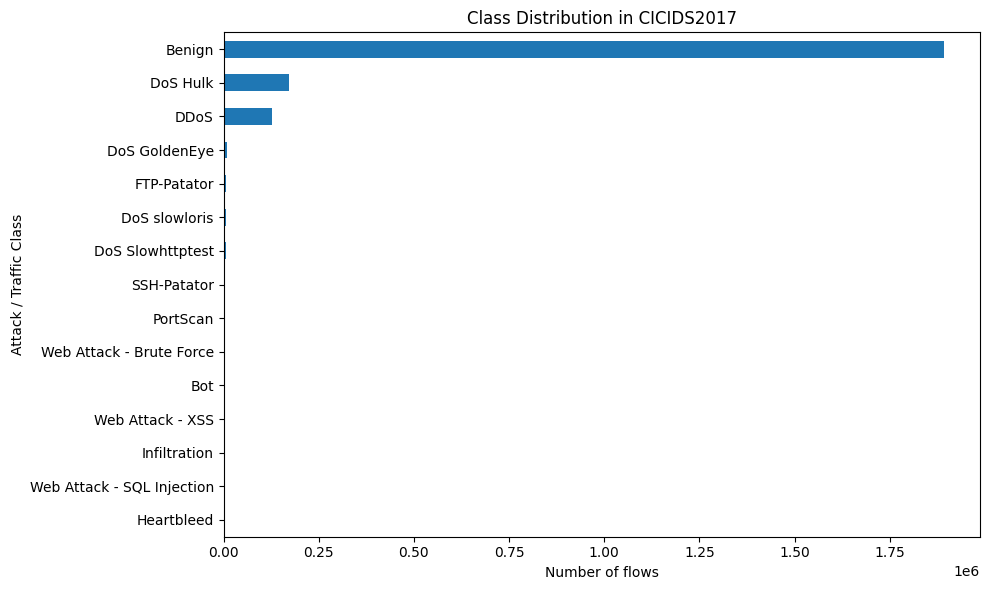

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

label_counts.sort_values().plot(
    kind="barh"
)

plt.xlabel("Number of flows")
plt.ylabel("Attack / Traffic Class")
plt.title("Class Distribution in CICIDS2017")

plt.tight_layout()
plt.show()

In [24]:
combined_df["Binary_Label"] = np.where(
    combined_df["Label"] == "Benign",
    "Benign",
    "Attack"
)

binary_counts = combined_df["Binary_Label"].value_counts()

print(binary_counts)

print("\nPercentages:")
print(
    (binary_counts / len(combined_df) * 100)
    .round(3)
)

Binary_Label
Benign    1892671
Attack     336299
Name: count, dtype: int64

Percentages:
Binary_Label
Benign    84.912
Attack    15.088
Name: count, dtype: float64


In [25]:
binary_labels = np.where(
    combined_df["Label"] == "Benign",
    "Benign",
    "Attack"
)

print(pd.Series(binary_labels).value_counts())

Benign    1892671
Attack     336299
Name: count, dtype: int64


In [26]:
binary_labels = np.where(
    combined_df["Label"] == "Benign",
    "Benign",
    "Attack"
)

binary_counts = pd.Series(binary_labels).value_counts()

print(binary_counts)

print("\nPercentages:")
print(
    (binary_counts / len(combined_df) * 100)
    .round(3)
)

Benign    1892671
Attack     336299
Name: count, dtype: int64

Percentages:
Benign    84.912
Attack    15.088
Name: count, dtype: float64


In [27]:
attack_df = combined_df[
    combined_df["Label"] != "Benign"
]

attack_counts = attack_df["Label"].value_counts()

print("Attack samples:", len(attack_df))
print("\nAttack distribution:")
print(attack_counts)

Attack samples: 336299

Attack distribution:
Label
DoS Hulk                      172688
DDoS                          127995
DoS GoldenEye                  10281
FTP-Patator                     5927
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3217
PortScan                        1956
Web Attack - Brute Force        1470
Bot                             1437
Web Attack - XSS                 652
Infiltration                      35
Web Attack - SQL Injection        21
Heartbleed                         7
Name: count, dtype: int64


In [28]:
attack_df = combined_df[
    combined_df["Label"] != "Benign"
]

attack_counts = attack_df["Label"].value_counts()

print("Attack samples:", len(attack_df))
print("\nAttack distribution:")
print(attack_counts)

Attack samples: 336299

Attack distribution:
Label
DoS Hulk                      172688
DDoS                          127995
DoS GoldenEye                  10281
FTP-Patator                     5927
DoS slowloris                   5385
DoS Slowhttptest                5228
SSH-Patator                     3217
PortScan                        1956
Web Attack - Brute Force        1470
Bot                             1437
Web Attack - XSS                 652
Infiltration                      35
Web Attack - SQL Injection        21
Heartbleed                         7
Name: count, dtype: int64


In [29]:
feature_cols = combined_df.select_dtypes(
    include=np.number
).columns

variance = combined_df[feature_cols].var().sort_values(
    ascending=False
)

print(variance.head(20))

Flow Duration    1.358470e+15
Fwd IAT Total    1.354855e+15
Bwd IAT Total    1.010192e+15
Fwd IAT Max      7.346837e+14
Flow IAT Max     7.294789e+14
Idle Max         7.271293e+14
Idle Mean        6.909555e+14
Idle Min         6.707575e+14
Bwd IAT Max      3.656726e+14
Fwd IAT Std      1.144071e+14
Fwd IAT Mean     1.130674e+14
Bwd IAT Mean     9.804352e+13
Fwd IAT Min      9.261814e+13
Bwd IAT Min      8.734872e+13
Flow IAT Std     8.003072e+13
Bwd IAT Std      4.816295e+13
Flow Bytes/s     3.836313e+13
Idle Std         2.656532e+13
Flow IAT Mean    2.466869e+13
Flow IAT Min     1.025983e+13
dtype: float64


In [30]:
summary = combined_df[feature_cols].describe().T

summary["missing"] = combined_df[feature_cols].isnull().sum()

summary["skewness"] = combined_df[feature_cols].skew()

summary.sort_values(
    "skewness",
    ascending=False
).head(20)

,count,mean,std,min,25%,50%,75%,max,missing,skewness
Subflow Bwd Bytes,2228970.0,6770.807540,2.822669e+05,0.0,36.000000,190.000000,3052.000000,3.993687e+08,0,1276.152316
Bwd Packets Length Total,2228970.0,6770.697087,2.820361e+05,0.0,36.000000,190.000000,3052.000000,3.990000e+08,0,1275.765893
Fwd Act Data Packets,2228970.0,3.518612,7.655269e+01,0.0,0.000000,1.000000,3.000000,1.082730e+05,0,1274.448500
Subflow Bwd Packets,2228970.0,6.826795,1.158872e+02,0.0,1.000000,2.000000,6.000000,1.573880e+05,0,1134.661108
Total Backward Packets,2228970.0,6.826795,1.158872e+02,0.0,1.000000,2.000000,6.000000,1.573880e+05,0,1134.661108
Subflow Fwd Packets,2228970.0,6.823366,8.368415e+01,1.0,2.000000,2.000000,6.000000,1.121410e+05,0,1095.210447
Total Fwd Packets,2228970.0,6.823366,8.368415e+01,1.0,2.000000,2.000000,6.000000,1.121410e+05,0,1095.210447
Bwd Header Length,2228970.0,181.125204,2.383097e+03,0.0,32.000000,64.000000,148.000000,3.147772e+06,0,1045.853168
Fwd Header Length,2228970.0,179.573633,1.809629e+03,0.0,40.000000,64.000000,172.000000,2.289684e+06,0,936.417944
Fwd Packets Length Total,2228970.0,660.831369,1.026370e+04,0.0,39.000000,74.000000,364.000000,1.290000e+07,0,921.962264


In [31]:
skewness = (
    combined_df[feature_cols]
    .skew()
    .abs()
    .sort_values(ascending=False)
)

print("Most skewed features:")
print(skewness.head(20))

Most skewed features:
Subflow Bwd Bytes           1276.152316
Bwd Packets Length Total    1275.765893
Fwd Act Data Packets        1274.448500
Subflow Bwd Packets         1134.661108
Total Backward Packets      1134.661108
Subflow Fwd Packets         1095.210447
Total Fwd Packets           1095.210447
Bwd Header Length           1045.853168
Fwd Header Length            936.417944
Fwd Packets Length Total     921.962264
Subflow Fwd Bytes            920.322714
CWE Flag Count               311.301895
Fwd URG Flags                311.301895
Flow Bytes/s                 173.484808
RST Flag Count                57.226757
ECE Flag Count                57.100823
Active Min                    39.946071
Active Std                    35.473206
Active Mean                   32.133186
Bwd Packets/s                 29.623678
dtype: float64


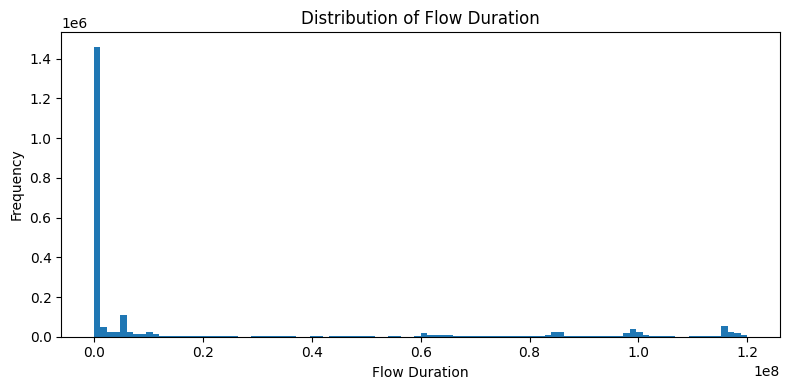

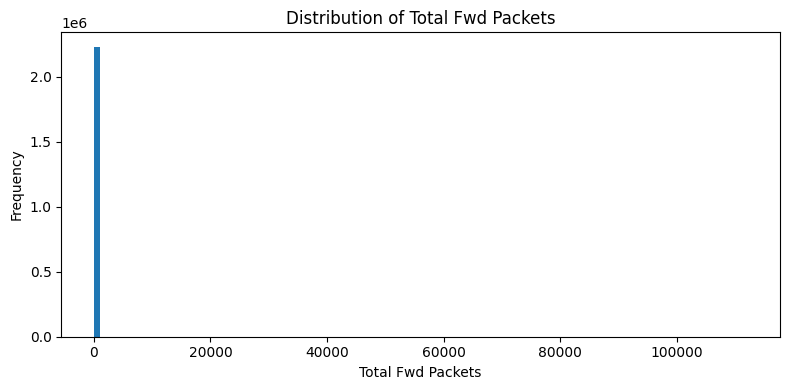

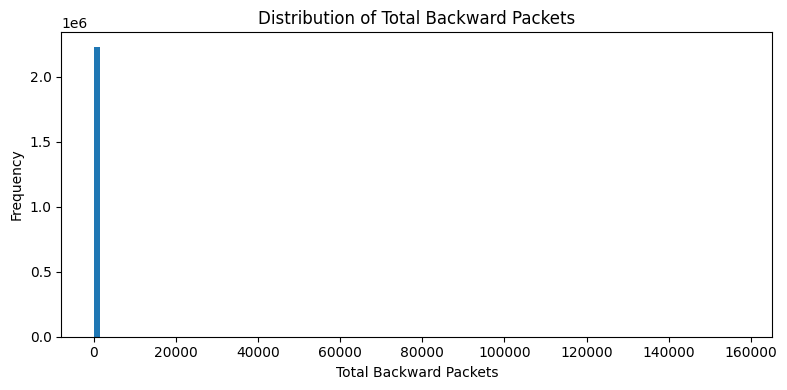

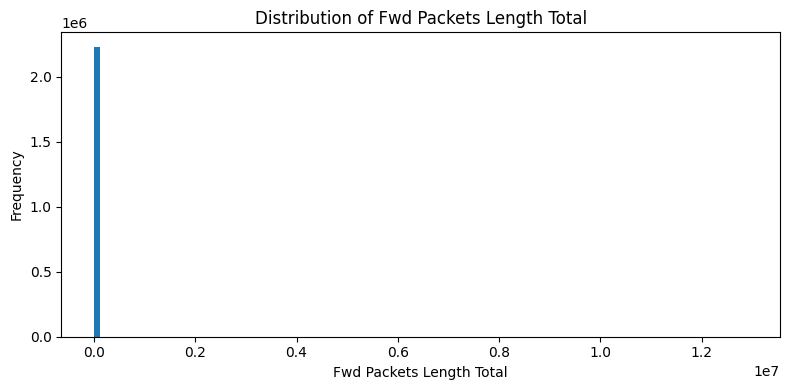

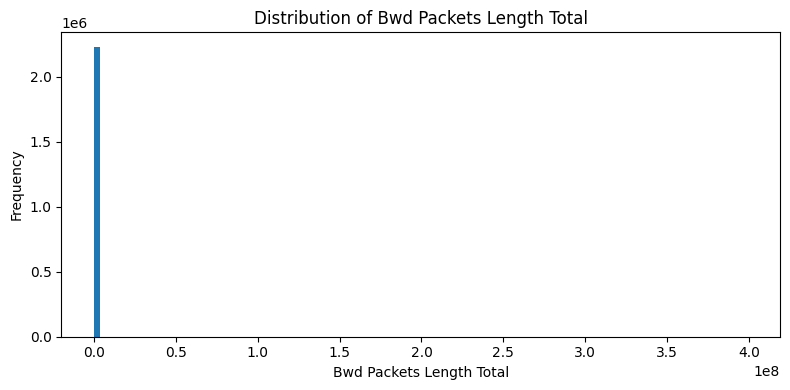

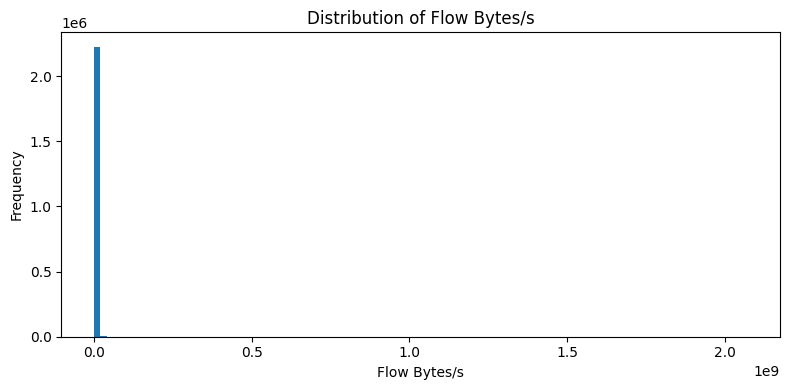

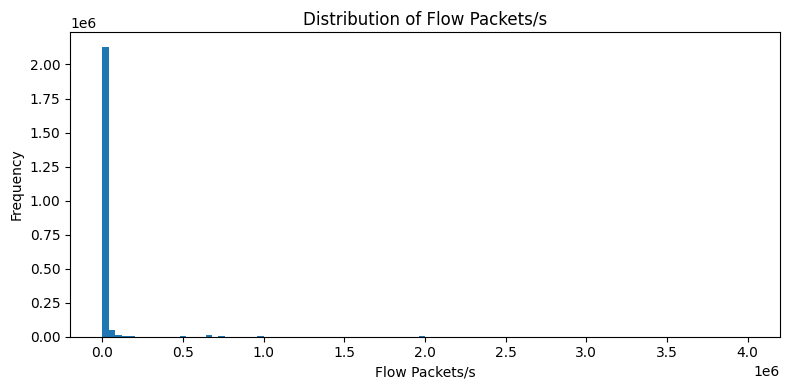

In [33]:
important_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Fwd Packets Length Total",
    "Bwd Packets Length Total",
    "Flow Bytes/s",
    "Flow Packets/s"
]

for col in important_features:

    plt.figure(figsize=(8, 4))

    plt.hist(
        combined_df[col].dropna(),
        bins=100
    )

    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")

    plt.tight_layout()
    plt.show()

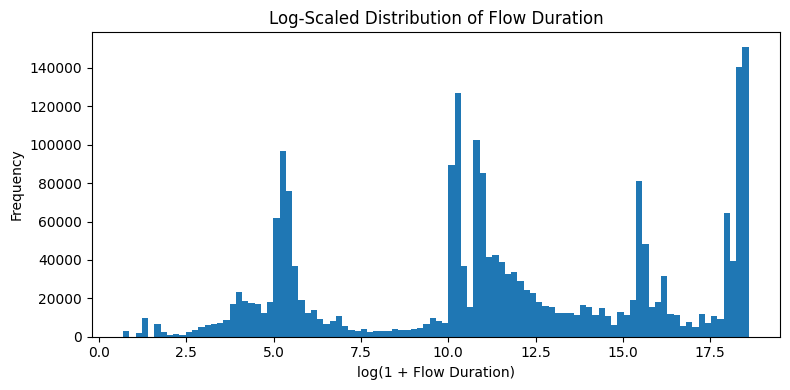

In [34]:
plt.figure(figsize=(8, 4))

plt.hist(
    np.log1p(
        combined_df["Flow Duration"].dropna()
    ),
    bins=100
)

plt.xlabel("log(1 + Flow Duration)")
plt.ylabel("Frequency")
plt.title("Log-Scaled Distribution of Flow Duration")

plt.tight_layout()
plt.show()

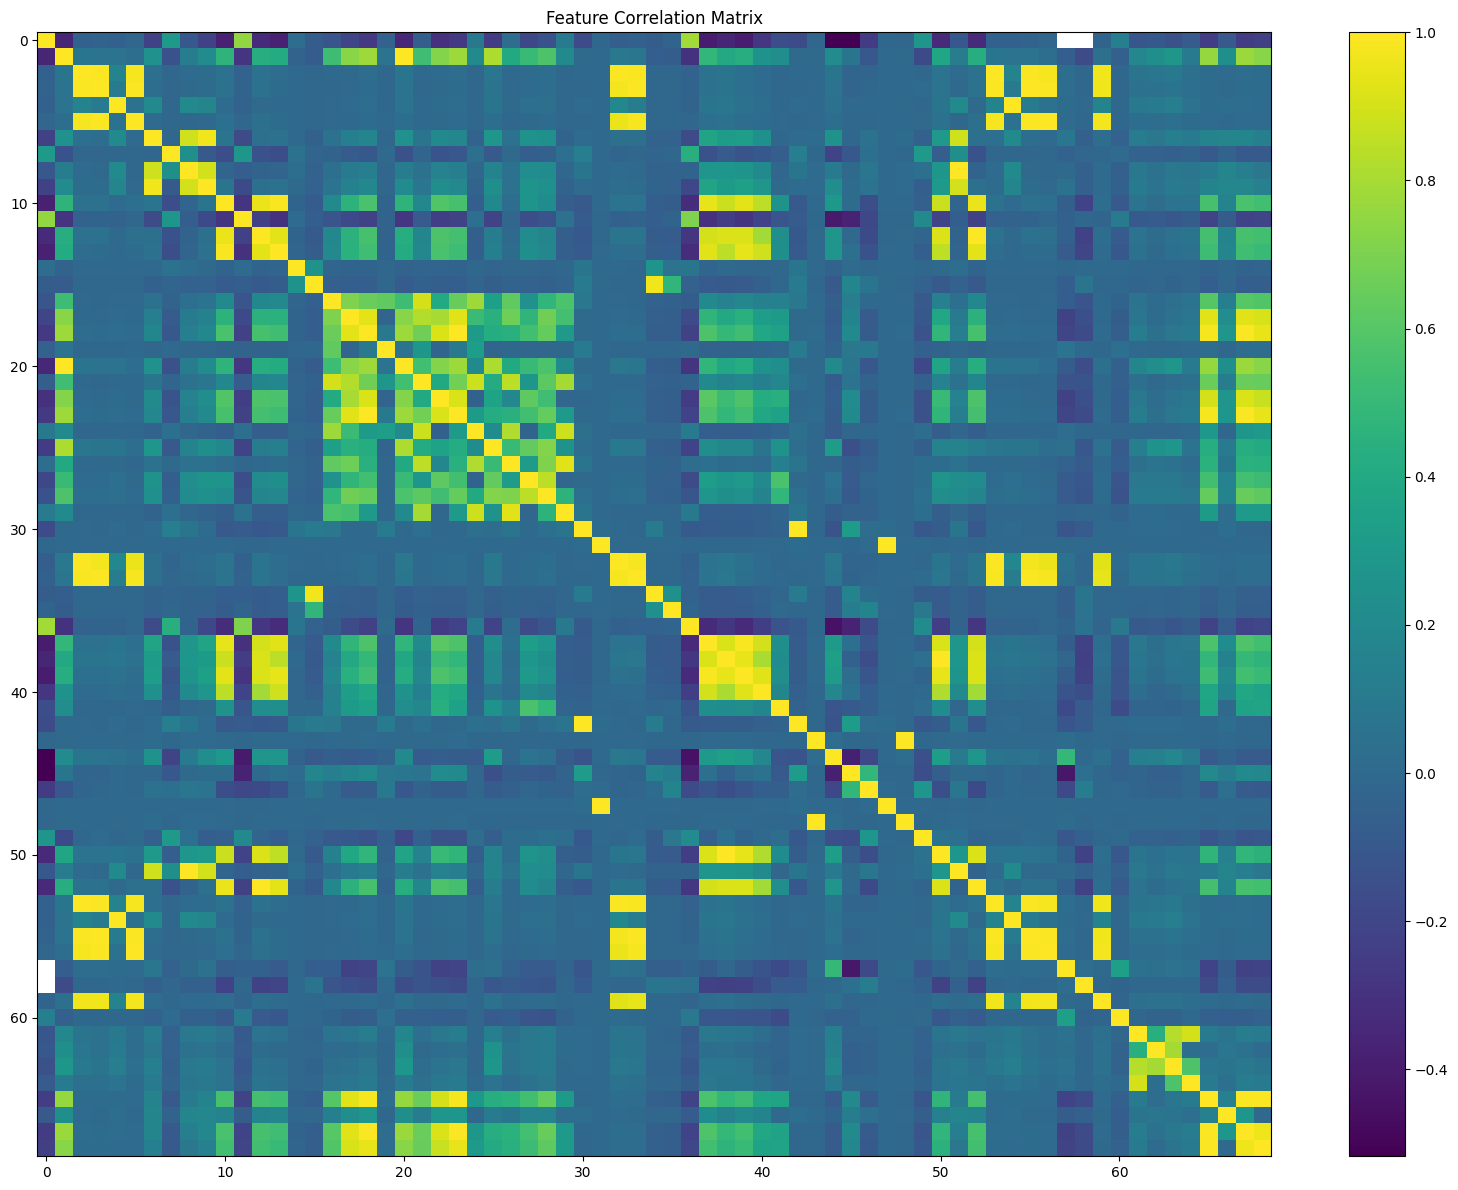

In [35]:
correlation_matrix = combined_df[
    feature_cols
].corr()

plt.figure(figsize=(16, 12))

plt.imshow(
    correlation_matrix,
    aspect="auto"
)

plt.colorbar()

plt.title("Feature Correlation Matrix")

plt.tight_layout()
plt.show()

In [36]:
corr_matrix = combined_df[feature_cols].corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(
        np.ones(corr_matrix.shape),
        k=1
    ).astype(bool)
)

high_corr_pairs = (
    upper_triangle
    .stack()
    .sort_values(ascending=False)
)

print("Highly correlated feature pairs:")
print(
    high_corr_pairs[high_corr_pairs > 0.90].head(30)
)

Highly correlated feature pairs:
Fwd URG Flags             CWE Flag Count              1.000000
Fwd PSH Flags             SYN Flag Count              1.000000
Fwd Packet Length Mean    Avg Fwd Segment Size        1.000000
Bwd Packet Length Mean    Avg Bwd Segment Size        1.000000
Total Backward Packets    Subflow Bwd Packets         1.000000
Total Fwd Packets         Subflow Fwd Packets         1.000000
Bwd Packets Length Total  Subflow Bwd Bytes           1.000000
Fwd Packets Length Total  Subflow Fwd Bytes           0.999999
Flow Duration             Fwd IAT Total               0.998505
Packet Length Mean        Avg Packet Size             0.998270
Flow IAT Max              Fwd IAT Max                 0.998040
RST Flag Count            ECE Flag Count              0.997801
Total Backward Packets    Bwd Header Length           0.993911
Bwd Header Length         Subflow Bwd Packets         0.993911
Total Fwd Packets         Subflow Bwd Packets         0.991607
                      

<Figure size 800x500 with 0 Axes>

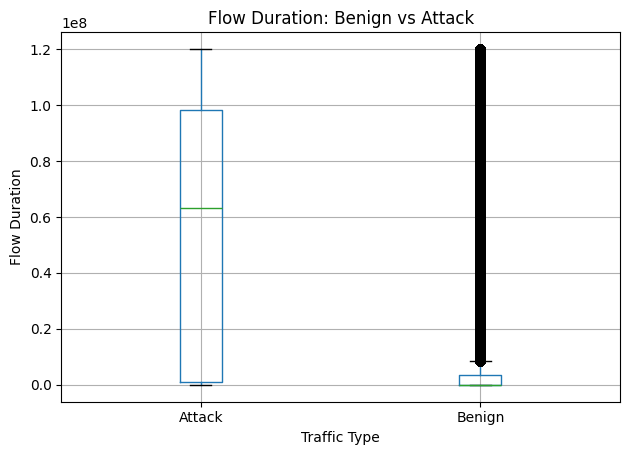

<Figure size 800x500 with 0 Axes>

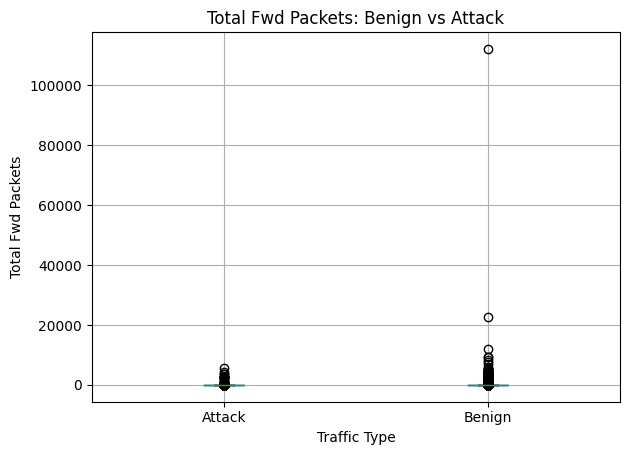

<Figure size 800x500 with 0 Axes>

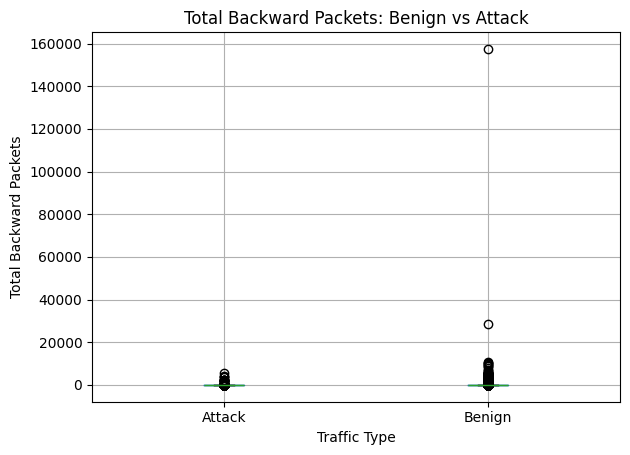

<Figure size 800x500 with 0 Axes>

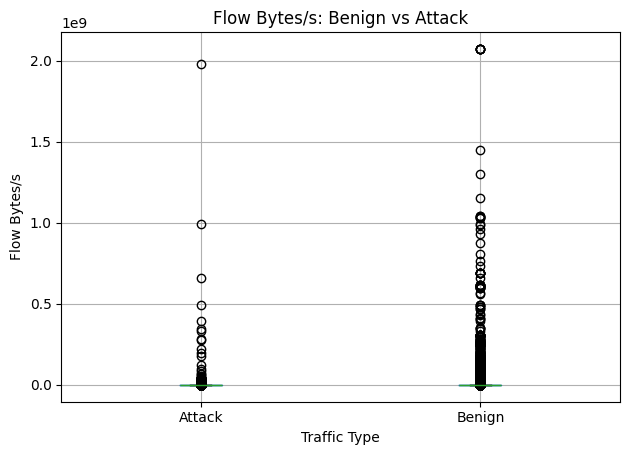

<Figure size 800x500 with 0 Axes>

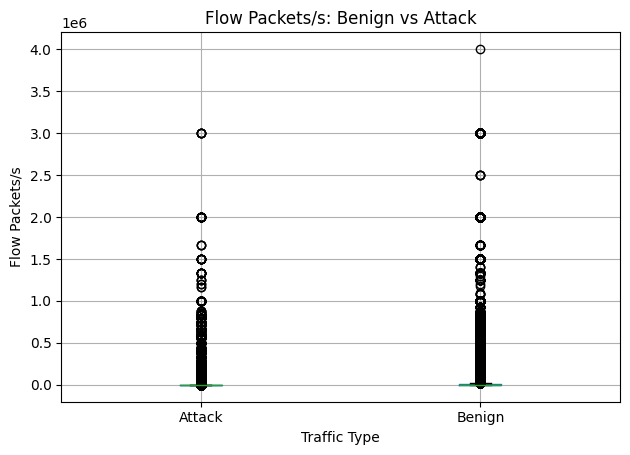

<Figure size 800x500 with 0 Axes>

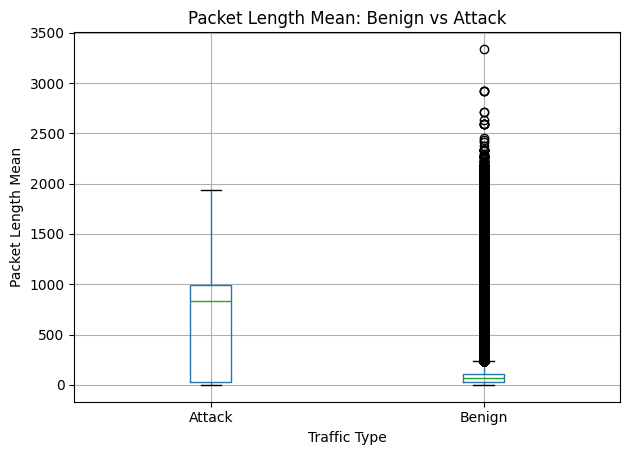

<Figure size 800x500 with 0 Axes>

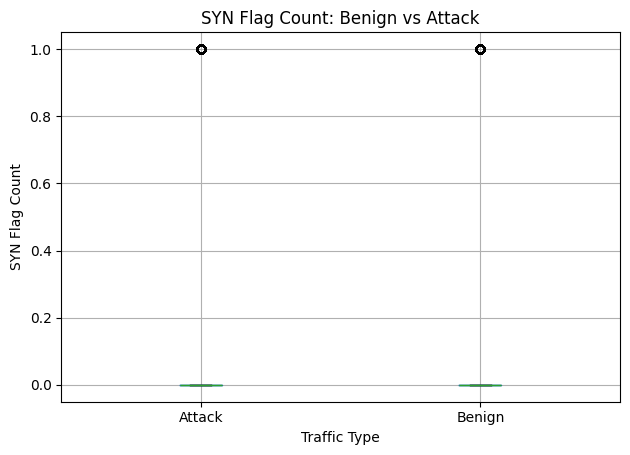

<Figure size 800x500 with 0 Axes>

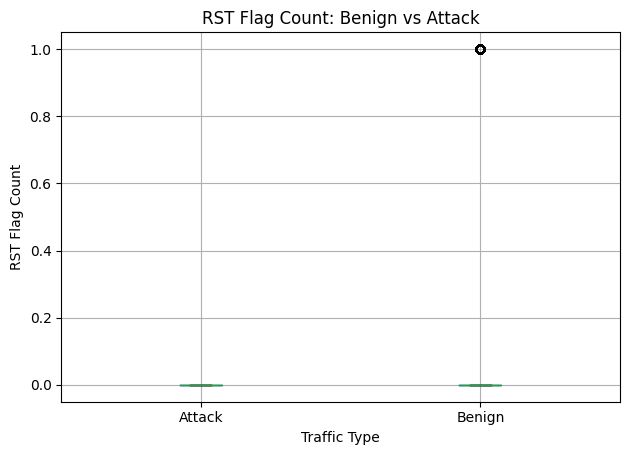

In [37]:
comparison_features = [
    "Flow Duration",
    "Total Fwd Packets",
    "Total Backward Packets",
    "Flow Bytes/s",
    "Flow Packets/s",
    "Packet Length Mean",
    "SYN Flag Count",
    "RST Flag Count"
]

eda_binary = combined_df.copy()

eda_binary["Traffic Type"] = np.where(
    eda_binary["Label"] == "Benign",
    "Benign",
    "Attack"
)

for col in comparison_features:

    plt.figure(figsize=(8, 5))

    eda_binary.boxplot(
        column=col,
        by="Traffic Type"
    )

    plt.title(f"{col}: Benign vs Attack")
    plt.suptitle("")

    plt.xlabel("Traffic Type")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In [38]:
median_comparison = (
    eda_binary
    .groupby("Traffic Type")[comparison_features]
    .median()
    .T
)

print(median_comparison)

Traffic Type                  Attack        Benign
Flow Duration           6.313518e+07  51622.000000
Total Fwd Packets       5.000000e+00      2.000000
Total Backward Packets  5.000000e+00      2.000000
Flow Bytes/s            1.383138e+02   3873.551522
Flow Packets/s          1.913239e-01     65.893516
Packet Length Mean      8.335000e+02     66.000000
SYN Flag Count          0.000000e+00      0.000000
RST Flag Count          0.000000e+00      0.000000


In [39]:
attack_feature_medians = (
    attack_df
    .groupby("Label")[comparison_features]
    .median()
)

print(attack_feature_medians)

                            Flow Duration  Total Fwd Packets  \
Label                                                          
Bot                               88782.0                4.0   
DDoS                            1879086.0                4.0   
DoS GoldenEye                  11588127.0                7.0   
DoS Hulk                       86402402.5                6.0   
DoS Slowhttptest               63120444.0                7.0   
DoS slowloris                  99999406.0                3.0   
FTP-Patator                     8686554.0                9.0   
Heartbleed                    119261118.0             2782.0   
Infiltration                   86726608.0               26.0   
PortScan                            674.0                2.0   
SSH-Patator                    12029814.0               21.0   
Web Attack - Brute Force        5567834.5                3.0   
Web Attack - SQL Injection      5006127.0                4.0   
Web Attack - XSS                5398909.

In [40]:
rare_classes = (
    combined_df["Label"]
    .value_counts()
    .sort_values()
)

print("Classes with fewer than 100 samples:")
print(
    rare_classes[rare_classes < 100]
)

Classes with fewer than 100 samples:
Label
Heartbleed                     7
Web Attack - SQL Injection    21
Infiltration                  35
Name: count, dtype: int64
